# Generate Images

In [1]:
import os
import pandas as pd
import random

import tomllib

import avoddiag as ag

## Load Configuration

In [2]:
with open("config/config.toml", "rb") as f:
    config = tomllib.load(f)

## Define Image Attributes

In [3]:
# Base attribute definitions
attributes_def_base = pd.DataFrame(
    [
        dict(
            name='scene_type',
            type=str,
            options=[
                'dense',
                'desert',
                'forest',
                'industrial',
                'plain',
                'residential',
                'rural',
                'scrubland',
                'urban'
            ],
            vqa_query='Describe the scene type of this aerial view image using a single expression.'
        ),
        dict(
            name='season',
            type=str,
            options=['spring', 'summer', 'fall', 'winter'],
            vqa_query='Which season does this aerial view image represent? Use a single word.'
        ),
        dict(
            name='weather',
            type=str,
            options=[
                'cloudy',
                'dry',
                'snowy',
                'sunny'
            ],
            vqa_query='Describe the weather conditions in this aerial view image using a single expression.'
        ),
        dict(
            name='vehicle_count',
            type=int,
            options=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
            vqa_query='How many vehicles are there in the image? Answer with a number.'
        ),
        dict(
            name='vehicle_colors',
            type=list[str],
            options=['brown', 'camo', 'green', 'black', 'red', 'white', 'blue', 'grey'],
            vqa_query='Provide a comma-separated list of the colors of the vehicles in this aerial view image. Use "camo" if a vehicle is camouflaged.'
        )

    ]
)

attributes_def_base

,name,type,options,vqa_query
0,scene_type,<class 'str'>,"[dense, desert, forest, industrial, plain, res...",Describe the scene type of this aerial view im...
1,season,<class 'str'>,"[spring, summer, fall, winter]",Which season does this aerial view image repre...
2,weather,<class 'str'>,"[cloudy, dry, snowy, sunny]",Describe the weather conditions in this aerial...
3,vehicle_count,<class 'int'>,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",How many vehicles are there in the image? Answ...
4,vehicle_colors,list[str],"[brown, camo, green, black, red, white, blue, ...",Provide a comma-separated list of the colors o...


In [4]:
# Generate image attributes from the base attribute definitions - uniformly and independently
k = 10
# random.seed(0)

dataset_attributes = {}
for i_attr, attr in attributes_def_base.iterrows():
    if attr['type'] in {str, int, float, bool}:
        values = random.choices(attr['options'], k=k)
        
    elif attr['type'] == list[str]:
        continue
        # values = [random.sample(attr['options'], k=random.randint(1, len(attr['options']))) for _ in range(k)]

    else:
        raise NotImplementedError(f"Attribute type {attr['type']} is not supported.")

    dataset_attributes[f"{attr['name']}"] = values

# vehicle_colors depend on vehicle_count, hence, it is generated after vehicle_count is available
vehicle_colors = []
for i, vehicle_count in enumerate(dataset_attributes['vehicle_count']):
    if vehicle_count == 0:
        vehicle_colors.append([])

    else:
        colors = sorted(
            set(
                random.choices(
                    attributes_def_base[attributes_def_base['name'] == 'vehicle_colors']['options'].values[0],
                    k=vehicle_count
                )
            )
        )
        vehicle_colors.append(colors)

dataset_attributes['vehicle_colors'] = vehicle_colors

dataset_attributes = pd.DataFrame(dataset_attributes)
dataset_attributes


,scene_type,season,weather,vehicle_count,vehicle_colors
0,industrial,spring,dry,1,[green]
1,scrubland,winter,snowy,15,"[blue, brown, green, red, white]"
2,desert,winter,dry,15,"[black, blue, brown, camo, grey, white]"
3,dense,winter,sunny,5,"[brown, camo, red, white]"
4,residential,fall,dry,3,"[blue, camo, grey]"
5,scrubland,summer,sunny,8,"[brown, camo, green, grey, red, white]"
6,industrial,fall,cloudy,3,"[blue, brown, camo]"
7,residential,fall,dry,11,"[black, blue, brown, green, grey, white]"
8,desert,fall,cloudy,0,[]
9,industrial,spring,dry,1,[red]


## Compose Prompts for Image Generation

### Initialize OpenAI Provider

In [5]:
provider_openai = ag.providers.openai.OpenAI(api_key=config['providers']['openai']['api_key'])

In [6]:
# List models
models_openai = provider_openai.list_models()
# models_openai
models_openai[models_openai['id'].apply(lambda x: x.find('gpt-5') != -1)]  # Filter models that contain 'gpt-5' in their name

,id,created,object,owned_by,shutdown_date
57,gpt-5-chat-latest,1754073306,model,system,2026-07-23
58,gpt-5-2025-08-07,1754075360,model,system,2026-12-11
59,gpt-5,1754425777,model,system,NaN
60,gpt-5-mini-2025-08-07,1754425867,model,system,2026-12-11
61,gpt-5-mini,1754425928,model,system,NaN
62,gpt-5-nano-2025-08-07,1754426303,model,system,2026-12-11
63,gpt-5-nano,1754426384,model,system,NaN
68,gpt-5-codex,1757527818,model,system,2026-07-23
70,gpt-5-pro-2025-10-06,1759469707,model,system,2026-12-11
71,gpt-5-pro,1759469822,model,system,NaN


### Query Provider

In [7]:
# Generate Prompts using OpenAI
from textwrap import dedent

instructions = dedent("""
    You are an expert prompt engineer generating realistic aerial image-generation prompts.

    You will receive a JSON array of records.

    Each record contains:
    - row_index (must be echoed unchanged)
    - scene_type
    - weather
    - season
    - vehicle_count
    - vehicle_colors
    - and possibly additional attributes.

    Generate exactly one output object for every input record.

    Requirements:

    1. Preserve every row.
    - Do not omit rows.
    - Do not merge rows.
    - Do not create extra rows.

    2. Echo row_index exactly as provided.

    3. Use only the provided attributes.
    - Do not invent attribute values.
    - If an attribute is missing or empty, make only the smallest realistic assumption.

    4. Prompt requirements:
    - straight-down (nadir, ~90° overhead) aerial view
    - photorealistic
    - neutral daylight unless weather or season implies otherwise
    - realistic scale
    - no artistic language
    - no camera brands or photography jargon
    - scene_type, weather, season, and vehicle attributes must be mutually consistent

    5. Vehicle colors:
    - If specified, include them.
    - If missing, use common realistic colors.

    6. Keep prompts concise:
    - one or two sentences
    - approximately 25–60 words

    Return only an object matching the PromptBatch schema.
""").strip()

dataset_prompts_data = provider_openai.generate_prompts(
    model_name="gpt-5",
    instructions=instructions,
    prompt_attributes=dataset_attributes,
)
dataset_prompts_data

Generating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-22 21:37:40.526819 Processing rows 0 to 10...
2026-09-22 21:38:18.521896 Completed rows 0 to 10.


,attribute:scene_type,attribute:season,attribute:weather,attribute:vehicle_count,attribute:vehicle_colors,prompt
0,industrial,spring,dry,1,[green],Straight-down aerial view of an industrial yar...
1,scrubland,winter,snowy,15,"[blue, brown, green, red, white]",Straight-down aerial view of snow-covered scru...
2,desert,winter,dry,15,"[black, blue, brown, camo, grey, white]",Straight-down aerial view of a dry winter dese...
3,dense,winter,sunny,5,"[brown, camo, red, white]",Straight-down aerial view of a dense winter fo...
4,residential,fall,dry,3,"[blue, camo, grey]",Straight-down aerial view of a residential nei...
5,scrubland,summer,sunny,8,"[brown, camo, green, grey, red, white]",Straight-down aerial view of summer scrubland ...
6,industrial,fall,cloudy,3,"[blue, brown, camo]",Straight-down aerial view of an industrial com...
7,residential,fall,dry,11,"[black, blue, brown, green, grey, white]",Straight-down aerial view of a fall residentia...
8,desert,fall,cloudy,0,[],Straight-down aerial view of a cloudy fall des...
9,industrial,spring,dry,1,[red],Straight-down aerial view of an industrial yar...


In [8]:
# Store prompts data (mainly for testing, datasets metadata will hold prompts)
os.makedirs("output", exist_ok=True)
dataset_prompts_data.to_json("output/dataset_prompts_data.json")

In [9]:
# Load prompts data
# dataset_prompts_data = pd.read_json("output/dataset_prompts_data.json")
# dataset_prompts_data

## Generate Images

### Initialize Google Provider

In [10]:
provider_google = ag.providers.google.GoogleGenAI(api_key=config['providers']['google']['api_key'])

In [11]:
# List models
models_google = provider_google.list_models()
# models_google # Uncomment to show all Google models
# models_google[models_google.name.apply(lambda x: x.lower().find('imagen') != -1)] # Uncommend to show only Imagen models
# models_google[models_google.name.apply(lambda x: x.find('gemini-2.5') != -1)]  # Uncommend to show only Gemini 2.5 models
models_google[models_google.name.apply(lambda x: x.find('gemini-3.1') != -1)]  # Uncommend to show only Gemini 3.1 models

,name,display_name,description,input_token_limit,output_token_limit,supported_actions,tuned_model_info,version
12,gemini-3.1-pro-preview,Gemini 3.1 Pro Preview,Gemini 3.1 Pro Preview,1048576,65536,"[generateContent, countTokens, createCachedCon...",base_model=None create_time=None update_time=None,3.1-pro-preview-01-2026
13,gemini-3.1-pro-preview-customtools,Gemini 3.1 Pro Preview Custom Tools,Gemini 3.1 Pro Preview optimized for custom to...,1048576,65536,"[generateContent, countTokens, createCachedCon...",base_model=None create_time=None update_time=None,3.1-pro-preview-01-2026
14,gemini-3.1-flash-lite-preview,Gemini 3.1 Flash Lite Preview,Gemini 3.1 Flash Lite Preview,1048576,65536,"[generateContent, countTokens, createCachedCon...",base_model=None create_time=None update_time=None,3.1-flash-lite-preview-03-2026
15,gemini-3.1-flash-lite,Gemini 3.1 Flash Lite,Gemini 3.1 Flash Lite,1048576,65536,"[generateContent, countTokens, createCachedCon...",base_model=None create_time=None update_time=None,3.1-flash-lite-05-2026
19,gemini-3.1-flash-image-preview,Nano Banana 2,Gemini 3.1 Flash Image Preview.,65536,65536,"[generateContent, countTokens, batchGenerateCo...",base_model=None create_time=None update_time=None,3.0
20,gemini-3.1-flash-image,Nano Banana 2,Gemini 3.1 Flash Image.,65536,65536,"[generateContent, countTokens, batchGenerateCo...",base_model=None create_time=None update_time=None,3.0
21,gemini-3.1-flash-lite-image,Nano Banana 2 Lite,Gemini 3.1 Flash Lite Image.,65536,65536,"[generateContent, countTokens, batchGenerateCo...",base_model=None create_time=None update_time=None,3.0
33,gemini-3.1-flash-tts-preview,Gemini 3.1 Flash TTS Preview,Gemini 3.1 Flash TTS Preview,8192,16384,"[generateContent, countTokens, batchGenerateCo...",base_model=None create_time=None update_time=None,3.1-flash-tts-preview
53,gemini-3.1-flash-live-preview,Gemini 3.1 Flash Live Preview,Gemini 3.1 Flash Live Preview,131072,65536,[bidiGenerateContent],base_model=None create_time=None update_time=None,3.1-flash-live-03-2026


### Query Provider

In [12]:
# Create an empty image dataset
image_dataset = ag.image.data.Dataset(root_folder_path="output/TestDataset_Generated_Images")

In [13]:
len(image_dataset)

0

In [14]:
# Create an image generator object
# model_name = "imagen-3.0-generate-002" # DEPRICATED
# model_name = "imagen-4.0-generate-001" # DEPRICATED
model_name = "gemini-3.1-flash-image"

image_generator = ag.image.generation.Generator(provider=provider_google, model_name=model_name)


In [15]:
image_generator.generate_dataset(
    image_dataset,
    metadata=dataset_prompts_data.copy()
)

Create dataset folders
Initiate image generation process


Generating images:   0%|          | 0/10 [00:00<?, ?it/s]

Finished generating images for 10 rows.
Saving metadata file "output/TestDataset_Generated_Images/metadata/attributes_input.json" | Saved 10 rows and 10 columns.
Finished saving metadata.
Load newly generated data.

Loading images data from  folder "images/"...
   Number of image files found: 10

Loading metadata...
   Key "attributes_input"  | Num. rows: 10 | Loaded from "metadata/attributes_input.json".


## Visualize Images

In [16]:
len(image_dataset)

10

In [17]:
image_dataset.metadata['attributes_input']

,attribute:scene_type,attribute:season,attribute:weather,attribute:vehicle_count,attribute:vehicle_colors,prompt,image_file_name,generation_status,exception,elapsed_time_sec
0,industrial,spring,dry,1,[green],Straight-down aerial view of an industrial yar...,000000.png,Success,NaN,10.244423
1,scrubland,winter,snowy,15,"[blue, brown, green, red, white]",Straight-down aerial view of snow-covered scru...,000001.png,Success,NaN,8.623361
2,desert,winter,dry,15,"[black, blue, brown, camo, grey, white]",Straight-down aerial view of a dry winter dese...,000002.png,Success,NaN,9.353084
3,dense,winter,sunny,5,"[brown, camo, red, white]",Straight-down aerial view of a dense winter fo...,000003.png,Success,NaN,10.445916
4,residential,fall,dry,3,"[blue, camo, grey]",Straight-down aerial view of a residential nei...,000004.png,Success,NaN,9.223215
5,scrubland,summer,sunny,8,"[brown, camo, green, grey, red, white]",Straight-down aerial view of summer scrubland ...,000005.png,Success,NaN,9.818688
6,industrial,fall,cloudy,3,"[blue, brown, camo]",Straight-down aerial view of an industrial com...,000006.png,Success,NaN,10.152267
7,residential,fall,dry,11,"[black, blue, brown, green, grey, white]",Straight-down aerial view of a fall residentia...,000007.png,Success,NaN,9.195346
8,desert,fall,cloudy,0,[],Straight-down aerial view of a cloudy fall des...,000008.png,Success,NaN,9.643899
9,industrial,spring,dry,1,[red],Straight-down aerial view of an industrial yar...,000009.png,Success,NaN,9.178166


In [18]:
image_dataset[0]

{'image_file_name': '000000.png',
 'image_file_path': 'output/TestDataset_Generated_Images/images/000000.png',
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 'metadata': {'attributes_input': attribute:scene_type                                               industrial
  attribute:season                                                       spring
  attribute:weather                                                         dry
  attribute:vehicle_count                                                     1
  attribute:vehicle_colors                                              [green]
  prompt                      Straight-down aerial view of an industrial yar...
  image_file_name                                                    000000.png
  generation_status                                                     Success
  exception                                                                 NaN
  elapsed_time_sec                                            

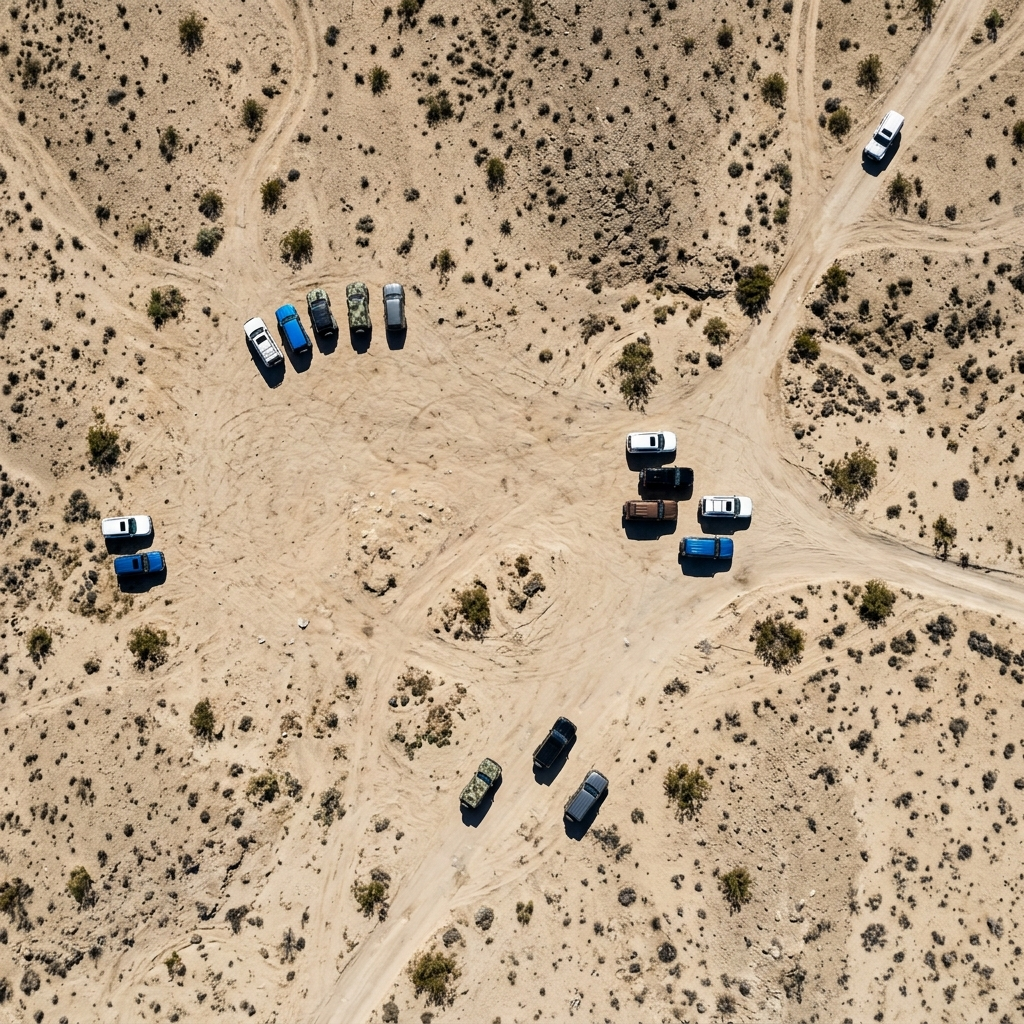

In [21]:
# Retrieve the image by file name
image_dataset['000002.png']['image']

Straight-down aerial view of a fall residential area with gridlike streets, dry asphalt, and trees showing mixed autumn colors. Eleven vehicles in black, blue, brown, green, grey, and white are scattered along curbs and driveways, neutral daylight, accurate road markings, realistic scale and shadows.


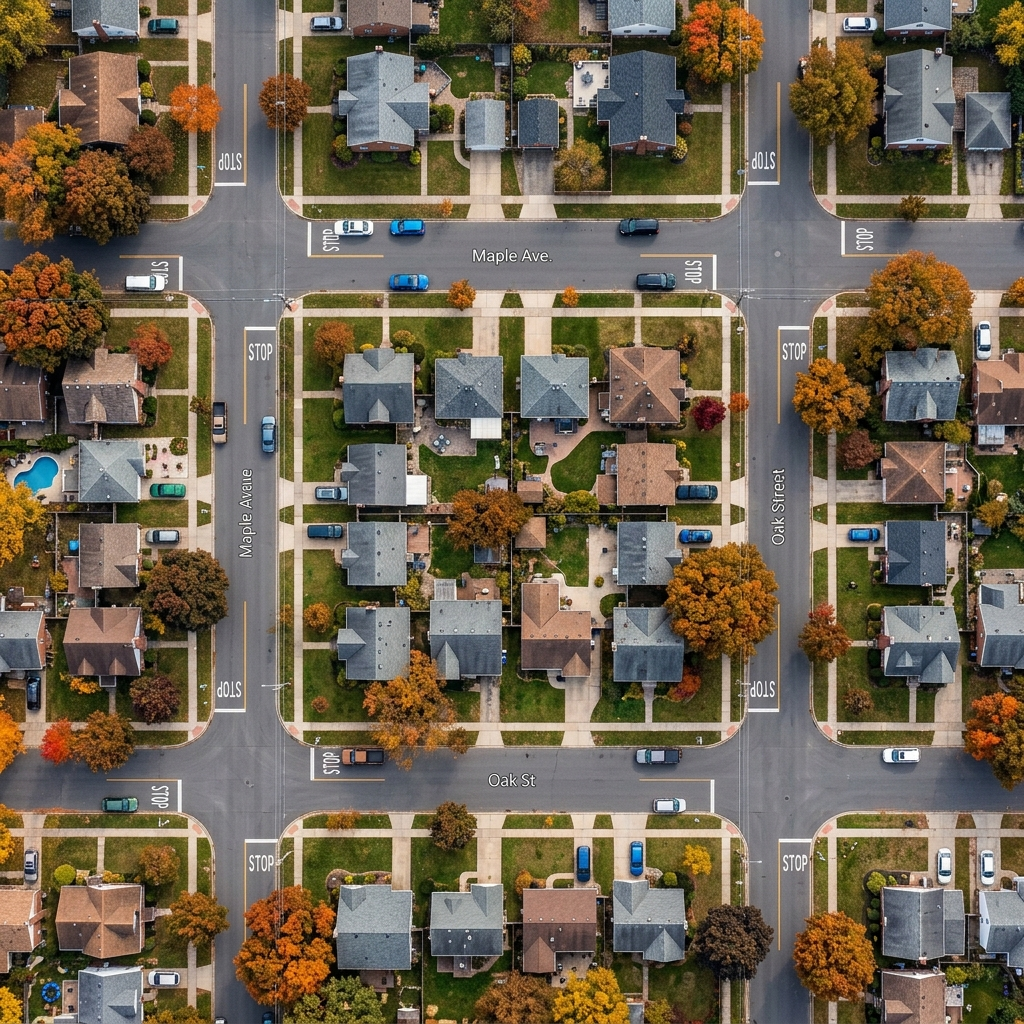

In [22]:
# Retrieve the image by index
import random

image_data = image_dataset[random.randint(0, len(image_dataset) - 1)]
print(image_data['metadata']['attributes_input']['prompt'])
image_data['image']